# 00 · Rewiring decisions, relationships, and evidence

**Decision question.** How could a heat outreach team connect evidence, community knowledge, and service access without turning a score into a decision?

**Time:** 30–45 minutes. **Prerequisites:** basic Python arrays and tables. Run cells from top to bottom.
The shared `rewiring.py` module must stay beside the notebooks. Initial package downloads require internet;
the core calculations use reproducible synthetic data. No health-service credentials are needed.

**Data contract:** the fictional grid is geographically anchored near Gaborone for teaching map coordinates.
Its people, facilities, climate, events, and model parameters are invented. It is **not a map of actual
Gaborone disease, vulnerability, buildings, or care access**. Satellite catalog metadata, when used, is labeled separately.

[Book](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/) · [Interactive demo gallery](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/demos/) · [Data and credits](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/DATA_SOURCES.md)

In [1]:
import sys
if sys.platform == 'emscripten':
    import micropip
    await micropip.install(['numpy', 'pandas', 'matplotlib'])
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, IFrame
from rewiring import (city, long_table, map_image, map_matrix, geojson,
                      leaflet, save_export, simulate_twin, teaching_review, HATS, SITE, LABEL, EXTENT)
plt.rcParams.update({'figure.dpi': 105, 'axes.spines.top': False, 'axes.spines.right': False})
cells, cube = city()
panel = long_table(cells, cube)
print(LABEL)
print('Python', sys.version.split()[0], '| cells:', len(cells), '| monthly observations:', len(panel))

SYNTHETIC teaching data · not observations or a forecast
Python 3.13.14 | cells: 64 | monthly observations: 1536


## From connectivity to cooperation

Tobias's Spatial Plexus presentation (2013, PDF pp. 2, 5, 12) frames rewiring as an invitation to
reconsider persistent problems, connect disciplines, and evaluate gains against possible harms.
Zuckerman's *Rewire* argues that technical connectivity alone does not ensure cross-cultural understanding.
Here that becomes a design question: whose knowledge enters an analysis, and whose voice can change it?

![Decision loop: evidence, models, community review, action, and learning](assets/decision-loop.svg)

The diagram is an original explanation, not an endorsement of any particular intervention.

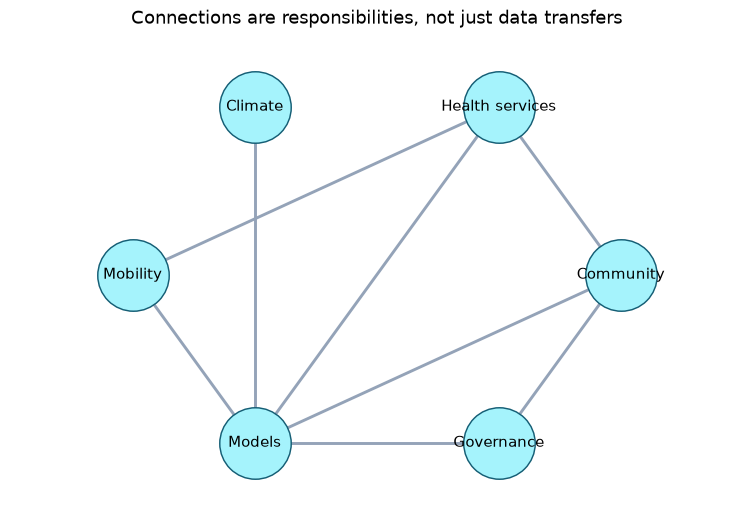

In [2]:
layers = ['Community', 'Health services', 'Climate', 'Mobility', 'Models', 'Governance']
angles = np.linspace(0, 2*np.pi, len(layers), endpoint=False)
xy = np.c_[np.cos(angles), np.sin(angles)]
edges = [(0,1),(0,5),(1,3),(1,4),(2,4),(3,4),(4,5),(0,4)]
fig, ax = plt.subplots(figsize=(9,6))
for i,j in edges:
    ax.plot(xy[[i,j],0], xy[[i,j],1], color='#94a3b8', lw=2)
ax.scatter(*xy.T, s=2400, color='#a5f3fc', edgecolors='#155e75', zorder=3)
for (x,y),name in zip(xy,layers): ax.text(x,y,name,ha='center',va='center',fontsize=10)
ax.set(xlim=(-1.5,1.5), ylim=(-1.25,1.25), title='Connections are responsibilities, not just data transfers')
ax.axis('off'); plt.show()

## Compare priorities and show the value choices

Heat, access, and vulnerability have different units. We normalize them to 0–1 within this synthetic
sample before weighting. Normalization makes arithmetic possible; it does not make the weights objective.
An outreach priority is not an individual risk prediction. Keep population denominators available.

,cell_id,population,access_min,vulnerability,priority
15,15,754,171.156522,0.807689,0.848082
7,7,1141,209.501614,0.666436,0.812876
23,23,2239,134.924439,0.840660,0.809632
14,14,1842,158.374811,0.729361,0.746808
63,63,2149,129.585553,0.567534,0.727491
13,13,2210,143.556988,0.768170,0.725301
6,6,559,198.546266,0.595805,0.724292
39,39,852,81.687481,0.741680,0.712341


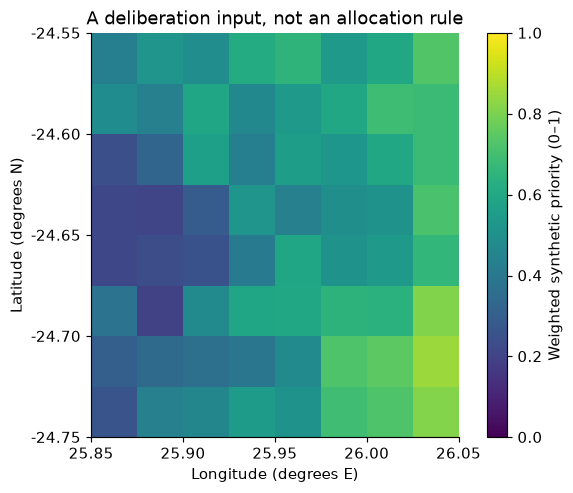

In [3]:
features = cells[['access_min','vulnerability']].copy()
features['heat_c'] = cube['heat_c'].mean(axis=0).ravel()
normalized = (features - features.min()) / (features.max() - features.min())
weights = np.array([.3,.4,.3])
cells['priority'] = normalized.to_numpy() @ weights
display(cells[['cell_id','population','access_min','vulnerability','priority']].nlargest(8,'priority'))
fig, ax = plt.subplots(figsize=(7,5))
im = map_image(ax, cells.priority.to_numpy().reshape(8,8), 'A deliberation input, not an allocation rule',0,1)
fig.colorbar(im, ax=ax, label='Weighted synthetic priority (0–1)'); plt.show()

## Would a different set of values change the map?

Compare an access-first, vulnerability-first, and heat-first policy with identical color limits.
A stable ranking across these alternatives is different from a ranking that depends on one choice of weights.
The weights below are examples for discussion; no ethical principle sets these numeric values.

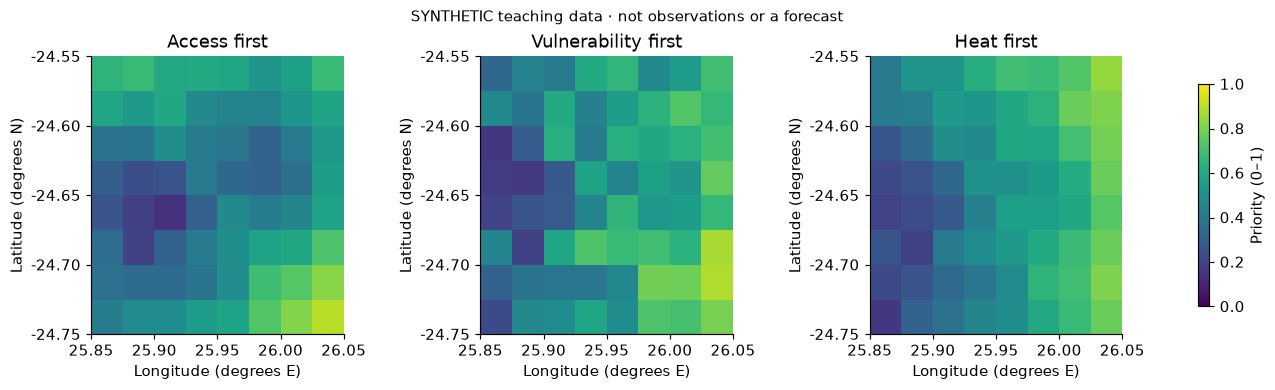

,Access first,Vulnerability first,Heat first
Top-eight Jaccard overlap,,,
Access first,1.000000,0.454545,0.333333
Vulnerability first,0.454545,1.000000,0.454545
Heat first,0.333333,0.454545,1.000000


In [4]:
policies = {'Access first': [.6,.2,.2], 'Vulnerability first':[.2,.6,.2], 'Heat first':[.2,.2,.6]}
scores = {name: normalized.to_numpy() @ w for name,w in policies.items()}
map_matrix([v.reshape(8,8) for v in scores.values()], list(scores), 'Priority (0–1)', limits=(0,1))
plt.show()
top_sets = {name:set(np.argsort(v)[-8:]) for name,v in scores.items()}
overlap = pd.DataFrame({a:{b:len(sa & sb)/len(sa | sb) for b,sb in top_sets.items()}
                        for a,sa in top_sets.items()})
display(overlap.rename_axis('Top-eight Jaccard overlap'))

## A decision record that keeps the human question visible

Record the intended benefit, uncertainty, community involvement, and a stop condition before a pilot.
The linked Public Health Informatics Case Studies provide another teaching pattern: reason from evidence
and test alternatives. The 1854 cholera examples are historical resources; the grid here is invented.

In [5]:
decision = {
 'question':'Where should a local team investigate heat outreach needs?',
 'evidence_status':'synthetic exercise; replace with governed local evidence',
 'alternatives':['universal outreach','community nominated sites','score assisted review'],
 'missing':['service capacity','community priorities','validated heat-health relationship'],
 'reviewers':['local health team','community representatives','privacy steward'],
 'stop_if':'The pilot displaces essential services or exposes sensitive locations.',
 'evaluation':'Compare reach, access gaps, costs, and adverse effects before expanding.'}
display(pd.Series(decision, name='Decision record'))
print(save_export('decision-record.json', decision))

question           Where should a local team investigate heat out...
evidence_status    synthetic exercise; replace with governed loca...
alternatives       [universal outreach, community nominated sites...
missing            [service capacity, community priorities, valid...
reviewers          [local health team, community representatives,...
stop_if            The pilot displaces essential services or expo...
evaluation         Compare reach, access gaps, costs, and adverse...
Name: Decision record, dtype: object

exports\decision-record.json


## Investigate, interpret, and discuss

1. Add a community-defined criterion. Explain how it would be collected and governed.
2. Compare the top eight cells under equal weights. Which cells are sensitive to the policy choice?
3. Propose a non-AI intervention and an outcome that would justify continuing it.

**Before sharing:** state the decision, data status, units, denominator, scale, uncertainty, and who can contest the result.
Record what would change your conclusion. Export only information that the intended audience needs.

## Sources and attribution

- Tobias, J. L. (2013), *Rewiring to meet the challenges of “Wicked Problems” within global and domestic Public Health*, supplied presentation, pp. 2, 5, 12.
- Zuckerman, E. (2013), *Rewire*. [Author's book page](https://ethanzuckerman.com/books/rewire/).
- [PHI Case Studies](https://github.com/PHI-Case-Studies) and [1854 cholera browser case study](https://phi-case-studies.github.io/Jupyterlite-1854-Cholera-Basic/lab/index.html).
- WHO (2021), [Ethics and governance of AI for health](https://www.who.int/publications/i/item/9789240029200).

Original lesson code: MIT. Original narrative, synthetic data, and generated figures: CC BY 4.0.
Third-party data, videos, services, and software retain their own terms.
[Full references](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/REFERENCES.md) · [Third-party notices](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/THIRD_PARTY_NOTICES.md).